# Image Analysis

This notebook analyzes image-level characteristics of the dermoscopic dataset. We examine dimensions, color distributions, and quality factors that inform preprocessing decisions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
import json
from tqdm import tqdm

In [2]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"

with open(PROJECT_ROOT / "config.json", "r") as f:
    CONFIG = json.load(f)

In [3]:
IMAGES_DIR_SEGMENTATION = RAW_DATA_DIR / "segmentation" / "ISIC_2019_Training_Input"
IMAGES_DIR_CLASSIFICATION = RAW_DATA_DIR / "classification" / "ISIC2019_Training_Input"
LABELS_PATH = RAW_DATA_DIR / "classification" / "ISIC_2019_Training_GroundTruth.csv"
labels_path = DATA_DIR / "labels_with_class.csv"

df = pd.read_csv(labels_path)
image_files = list(IMAGES_DIR_CLASSIFICATION.glob("*.jpg"))

print(f"Found {len(image_files)} images")

Found 10015 images


In [4]:
# Sample subset for analysis (analyzing all images would be time-consuming)
np.random.seed(42)
sample_size = min(500, len(image_files))
sample_files = np.random.choice(image_files, size=sample_size, replace=False)

print(f"Analyzing {sample_size} sample images")

Analyzing 500 sample images


In [5]:
dimensions = []

for img_path in tqdm(sample_files, desc="Collecting dimensions"):
    img = Image.open(img_path)
    width, height = img.size
    dimensions.append({
        "filename": img_path.name,
        "width": width,
        "height": height,
        "aspect_ratio": width / height
    })

df_dims = pd.DataFrame(dimensions)

In [6]:
print("Dimension Statistics:")
print(df_dims[["width", "height", "aspect_ratio"]].describe())

Dimension Statistics:
       width  height  aspect_ratio
count  500.0   500.0  5.000000e+02
mean   600.0   450.0  1.333333e+00
std      0.0     0.0  2.222670e-16
min    600.0   450.0  1.333333e+00
25%    600.0   450.0  1.333333e+00
50%    600.0   450.0  1.333333e+00
75%    600.0   450.0  1.333333e+00
max    600.0   450.0  1.333333e+00


The dimension statistics reveal image size variability. Understanding this helps determine appropriate resizing strategy.

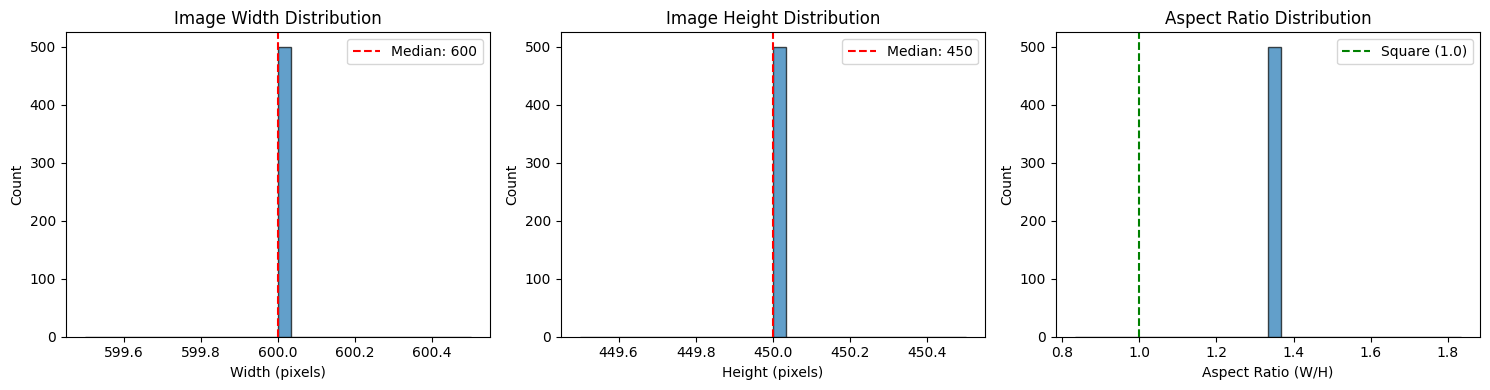

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_dims["width"], bins=30, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Width (pixels)")
axes[0].set_ylabel("Count")
axes[0].set_title("Image Width Distribution")
axes[0].axvline(df_dims["width"].median(), color="red", linestyle="--", label=f"Median: {df_dims['width'].median():.0f}")
axes[0].legend()

axes[1].hist(df_dims["height"], bins=30, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Height (pixels)")
axes[1].set_ylabel("Count")
axes[1].set_title("Image Height Distribution")
axes[1].axvline(df_dims["height"].median(), color="red", linestyle="--", label=f"Median: {df_dims['height'].median():.0f}")
axes[1].legend()

axes[2].hist(df_dims["aspect_ratio"], bins=30, edgecolor="black", alpha=0.7)
axes[2].set_xlabel("Aspect Ratio (W/H)")
axes[2].set_ylabel("Count")
axes[2].set_title("Aspect Ratio Distribution")
axes[2].axvline(1.0, color="green", linestyle="--", label="Square (1.0)")
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "dimension_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
unique_sizes = df_dims.groupby(["width", "height"]).size().reset_index(name="count")
unique_sizes = unique_sizes.sort_values("count", ascending=False)

print(f"Number of unique dimension combinations: {len(unique_sizes)}")
print("\nTop 10 most common dimensions:")
print(unique_sizes.head(10))

Number of unique dimension combinations: 1

Top 10 most common dimensions:
   width  height  count
0    600     450    500


Multiple unique dimensions exist, confirming the need for resizing during preprocessing. The target size of 256x256 will normalize all images.

In [9]:
def compute_color_stats(img_path):
    """Compute color statistics for an image."""
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    stats = {}
    for i, channel in enumerate(["R", "G", "B"]):
        ch = img_rgb[:, :, i].flatten()
        stats[f"{channel}_mean"] = ch.mean()
        stats[f"{channel}_std"] = ch.std()
        stats[f"{channel}_min"] = ch.min()
        stats[f"{channel}_max"] = ch.max()
    
    # Overall brightness
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    stats["brightness_mean"] = gray.mean()
    stats["brightness_std"] = gray.std()
    
    return stats

In [10]:
color_stats = []

for img_path in tqdm(sample_files[:200], desc="Computing color statistics"):
    stats = compute_color_stats(img_path)
    stats["filename"] = img_path.name
    color_stats.append(stats)

df_colors = pd.DataFrame(color_stats)

Computing color statistics: 100%|██████████| 200/200 [00:02<00:00, 69.40it/s]


In [11]:
df_colors.head()

,R_mean,R_std,R_min,R_max,G_mean,G_std,G_min,G_max,B_mean,B_std,B_min,B_max,brightness_mean,brightness_std,filename
0,206.308181,30.570679,53,243,124.062119,31.400623,8,169,151.868689,35.061714,23,196,151.830252,31.299229,ISIC_0025923.jpg
1,195.535622,26.119740,109,254,124.800022,36.527088,26,224,155.892881,39.312370,59,254,149.516970,33.496058,ISIC_0032434.jpg
2,206.504241,27.399829,87,252,125.319359,34.279507,24,186,133.500211,36.704323,22,196,150.541130,32.182264,ISIC_0026474.jpg
3,210.236215,28.885739,58,240,189.976485,48.744152,11,229,195.474548,51.763676,10,251,196.676863,42.973838,ISIC_0025396.jpg
4,249.328319,8.374650,187,255,171.827833,21.527587,59,220,168.921400,33.737330,26,228,194.691144,18.678155,ISIC_0032060.jpg


In [12]:
print("Color Channel Statistics (across sample):")
print(df_colors[["R_mean", "G_mean", "B_mean", "brightness_mean"]].describe())

Color Channel Statistics (across sample):
           R_mean      G_mean      B_mean  brightness_mean
count  200.000000  200.000000  200.000000       200.000000
mean   197.630427  140.695063  146.792490       158.423996
std     24.276098   21.812157   23.757422        18.729566
min    131.978619   92.382967   86.405881       118.359389
25%    179.969817  125.081622  130.929325       144.939459
50%    199.782402  138.928641  145.851596       157.407046
75%    215.167091  156.085175  163.813197       171.540744
max    249.697793  193.849141  208.150415       204.557319


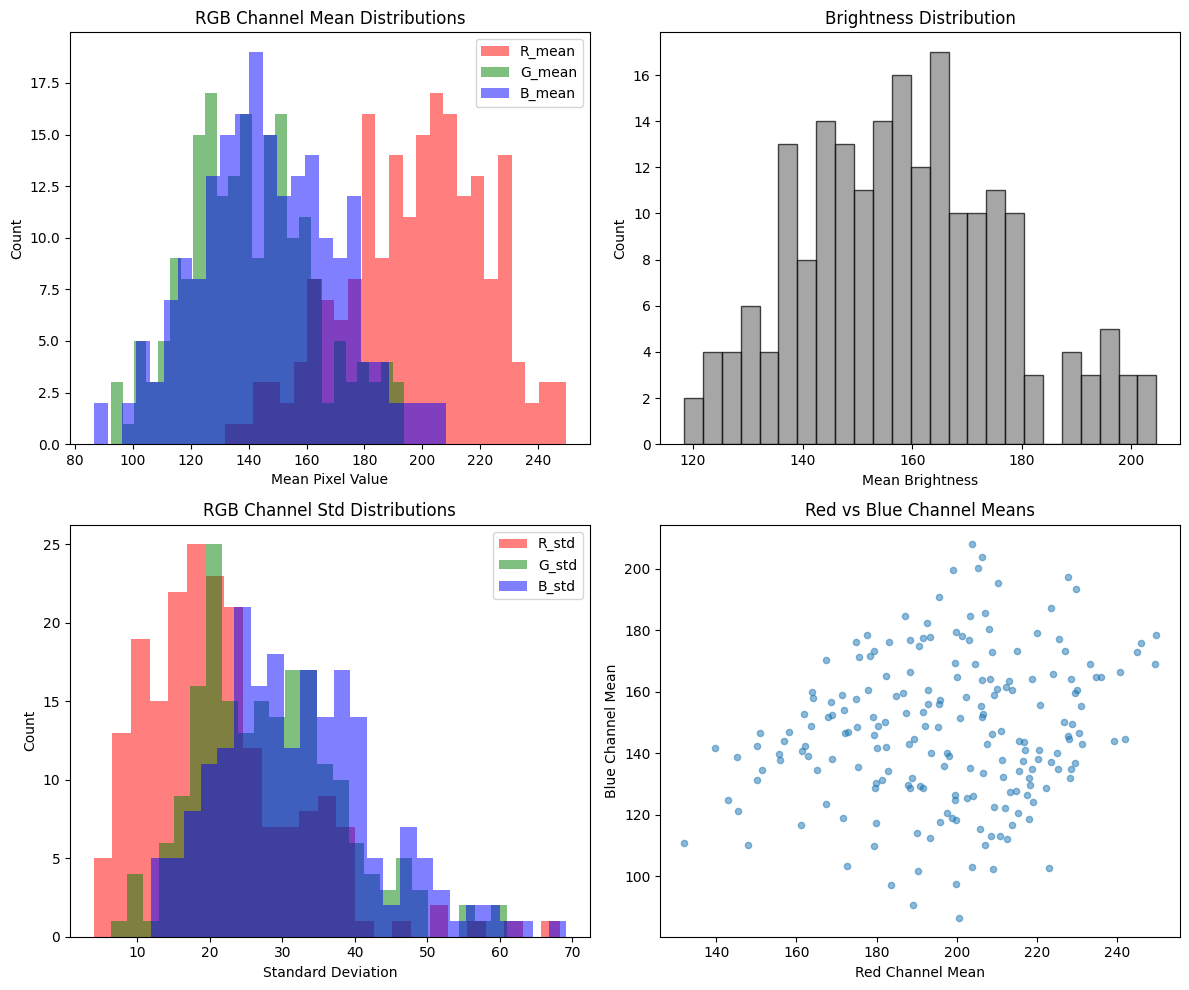

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

colors_list = ["red", "green", "blue"]
for i, (col, color) in enumerate(zip(["R_mean", "G_mean", "B_mean"], colors_list)):
    axes[0, 0].hist(df_colors[col], bins=25, alpha=0.5, label=col, color=color)
axes[0, 0].set_xlabel("Mean Pixel Value")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("RGB Channel Mean Distributions")
axes[0, 0].legend()

axes[0, 1].hist(df_colors["brightness_mean"], bins=25, edgecolor="black", alpha=0.7, color="gray")
axes[0, 1].set_xlabel("Mean Brightness")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Brightness Distribution")

for i, (col, color) in enumerate(zip(["R_std", "G_std", "B_std"], colors_list)):
    axes[1, 0].hist(df_colors[col], bins=25, alpha=0.5, label=col, color=color)
axes[1, 0].set_xlabel("Standard Deviation")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("RGB Channel Std Distributions")
axes[1, 0].legend()

axes[1, 1].scatter(df_colors["R_mean"], df_colors["B_mean"], alpha=0.5, s=20)
axes[1, 1].set_xlabel("Red Channel Mean")
axes[1, 1].set_ylabel("Blue Channel Mean")
axes[1, 1].set_title("Red vs Blue Channel Means")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "color_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

Color analysis reveals:
- Red channel tends to have higher mean values (typical for skin tones)
- Brightness varies significantly across images (supports need for CLAHE)
- Standard deviation varies, indicating different contrast levels

In [14]:
def analyze_potential_artifacts(img_path):
    """Basic analysis for potential artifacts like hair."""
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Dark line detection (potential hair)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    
    dark_pixels = np.sum(blackhat > 10)
    total_pixels = gray.size
    dark_ratio = dark_pixels / total_pixels
    
    return {
        "filename": img_path.name,
        "dark_line_ratio": dark_ratio,
        "potential_hair": dark_ratio > 0.02
    }

In [15]:
artifact_analysis = []

for img_path in tqdm(sample_files[:200], desc="Analyzing artifacts"):
    result = analyze_potential_artifacts(img_path)
    artifact_analysis.append(result)

df_artifacts = pd.DataFrame(artifact_analysis)

Analyzing artifacts: 100%|██████████| 200/200 [00:02<00:00, 83.78it/s]


In [16]:
hair_count = df_artifacts["potential_hair"].sum()
total_analyzed = len(df_artifacts)

print(f"Images with potential hair artifacts: {hair_count}/{total_analyzed} ({hair_count/total_analyzed*100:.1f}%)")

Images with potential hair artifacts: 196/200 (98.0%)


In [17]:
image_analysis_summary = {
    "sample_size": sample_size,
    "dimension_stats": {
        "width_median": float(df_dims["width"].median()),
        "height_median": float(df_dims["height"].median()),
        "unique_dimensions": len(unique_sizes)
    },
    "color_stats": {
        "brightness_mean": float(df_colors["brightness_mean"].mean()),
        "brightness_std": float(df_colors["brightness_mean"].std()),
        "red_mean": float(df_colors["R_mean"].mean()),
        "green_mean": float(df_colors["G_mean"].mean()),
        "blue_mean": float(df_colors["B_mean"].mean())
    },
    "artifact_analysis": {
        "potential_hair_percentage": float(hair_count / total_analyzed * 100)
    }
}

with open(RESULTS_DIR / "image_analysis_summary.json", "w") as f:
    json.dump(image_analysis_summary, f, indent=2)
    
print("Image analysis summary saved.")

Image analysis summary saved.
